In [33]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [34]:
ROOT = Path.cwd().parent

baseline = pd.read_csv(
    ROOT / "data" / "processed" / "dataset_regresion_baseline.csv"
)

dominio = pd.read_csv(
    ROOT / "data" / "processed" / "dataset_regresion_dominio.csv"
)

ampliado = pd.read_csv(
    ROOT / "data" / "processed" / "dataset_regresion_ampliado.csv"
)

print("Baseline :", baseline.shape)
print("Dominio  :", dominio.shape)
print("Ampliado :", ampliado.shape)

Baseline : (1737, 13)
Dominio  : (1737, 17)
Ampliado : (1737, 97)


In [35]:
def evaluar_dataset_regresion(dataset, nombre_dataset):
    X = dataset.drop(columns=["IMC"])
    y = dataset["IMC"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    modelos = {
        "Regresión Lineal": Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),

        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("model", RandomForestRegressor(
                n_estimators=200,
                random_state=42
            ))
        ]),

        "Gradient Boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("model", GradientBoostingRegressor(
                random_state=42
            ))
        ])
    }

    resultados = []

    for nombre_modelo, modelo in modelos.items():
        modelo.fit(X_train, y_train)

        pred = modelo.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)
        r2 = r2_score(y_test, pred)

        scores_cv = cross_val_score(
            modelo,
            X,
            y,
            cv=5,
            scoring="neg_root_mean_squared_error"
        )

        resultados.append({
            "Dataset": nombre_dataset,
            "Modelo": nombre_modelo,
            "RMSE_Test": rmse,
            "MAE_Test": mae,
            "R2_Test": r2,
            "RMSE_CV_Media": -scores_cv.mean(),
            "RMSE_CV_Std": scores_cv.std()
        })

    return pd.DataFrame(resultados)

In [36]:
resultados_baseline = evaluar_dataset_regresion(
    baseline,
    "Baseline"
)

resultados_dominio = evaluar_dataset_regresion(
    dominio,
    "Dominio"
)

resultados_ampliado = evaluar_dataset_regresion(
    ampliado,
    "Ampliado"
)

In [37]:
resultados = pd.concat(
    [
        resultados_baseline,
        resultados_dominio,
        resultados_ampliado
    ],
    ignore_index=True
)

resultados.sort_values("RMSE_Test")

,Dataset,Modelo,RMSE_Test,MAE_Test,R2_Test,RMSE_CV_Media,RMSE_CV_Std
3,Dominio,Regresión Lineal,3.893067,2.985265,0.019903,4.126199,0.160657
0,Baseline,Regresión Lineal,3.902247,3.009348,0.015275,4.128507,0.156219
4,Dominio,Random Forest,4.027640,3.127244,-0.049027,4.290493,0.235269
2,Baseline,Gradient Boosting,4.050460,3.140024,-0.060948,4.204445,0.168059
7,Ampliado,Random Forest,4.054787,3.177601,-0.063216,4.240678,0.175258
6,Ampliado,Regresión Lineal,4.056217,3.136138,-0.063966,4.308905,0.182804
5,Dominio,Gradient Boosting,4.103232,3.161552,-0.088773,4.271392,0.189438
8,Ampliado,Gradient Boosting,4.238247,3.209954,-0.161603,4.302885,0.202274
1,Baseline,Random Forest,4.400066,3.314943,-0.251998,4.627485,0.179221


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

In [39]:
X = dominio.drop(columns=["IMC"])
y = dominio["IMC"]

imputer = SimpleImputer(strategy="most_frequent")

X_imp = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [40]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_imp, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [41]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importancias = importancias.sort_values(
    "Importancia",
    ascending=False
)

importancias

,Variable,Importancia
12,Q49,0.087552
6,Q9,0.085120
4,Q7,0.082443
15,Q52,0.078101
5,Q8,0.076557
7,Q10,0.073646
8,Q11,0.070292
13,Q50,0.065903
14,Q51,0.064461
0,Q1,0.064423


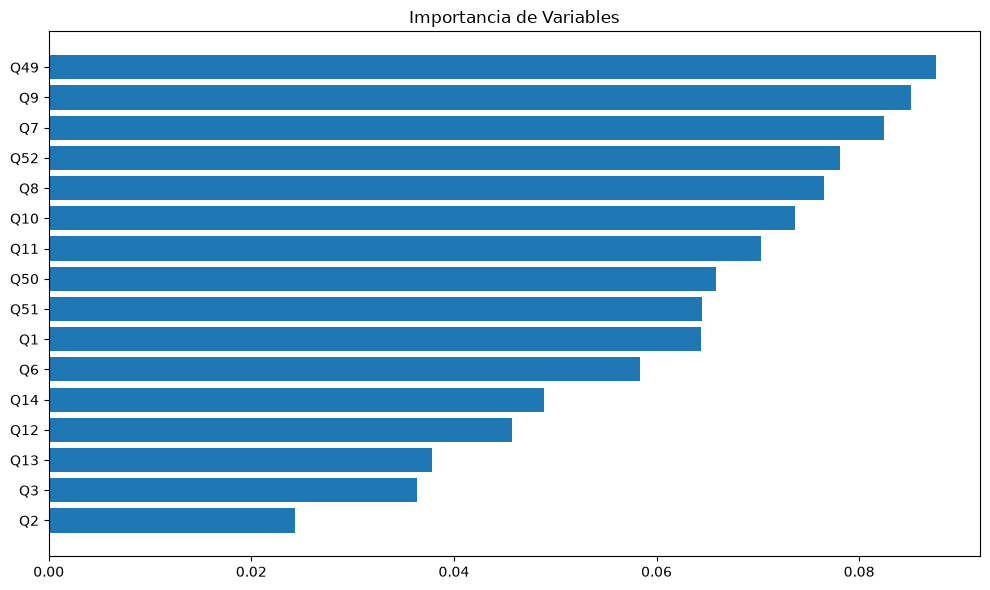

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.title("Importancia de Variables")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [43]:
# Seleccionar automáticamente las 12 variables más importantes
features_final = importancias.head(12)["Variable"].tolist()

print("Variables seleccionadas:")
print(features_final)

Variables seleccionadas:
['Q49', 'Q9', 'Q7', 'Q52', 'Q8', 'Q10', 'Q11', 'Q50', 'Q51', 'Q1', 'Q6', 'Q14']


In [44]:
dataset_final = dominio[
    features_final + ["IMC"]
].copy()

dataset_final.head()

,Q49,Q9,Q7,Q52,Q8,Q10,Q11,Q50,Q51,Q1,Q6,Q14,IMC
0,3.0,1.0,2.0,1.0,1.0,1.0,4.0,1.0,2.0,4.0,1.0,5.0,19.067711
1,4.0,4.0,2.0,4.0,2.0,2.0,2.0,1.0,2.0,3.0,3.0,3.0,20.690495
2,3.0,2.0,3.0,3.0,1.0,1.0,3.0,1.0,2.0,4.0,2.0,3.0,18.442546
3,1.0,4.0,3.0,1.0,3.0,7.0,5.0,2.0,6.0,5.0,1.0,5.0,31.501096
4,2.0,4.0,4.0,1.0,2.0,1.0,3.0,2.0,2.0,3.0,1.0,5.0,23.456558


In [45]:
resultados_final = evaluar_dataset_regresion(
    dataset_final,
    "Optimizado"
)

resultados_final

,Dataset,Modelo,RMSE_Test,MAE_Test,R2_Test,RMSE_CV_Media,RMSE_CV_Std
0,Optimizado,Regresión Lineal,3.937675,3.031580,-0.002686,4.143182,0.167001
1,Optimizado,Random Forest,4.055084,3.178670,-0.063372,4.354457,0.225088
2,Optimizado,Gradient Boosting,4.105681,3.198096,-0.090073,4.277112,0.180518


In [46]:
resultados_completos = pd.concat([
    resultados_baseline,
    resultados_dominio,
    resultados_ampliado,
    resultados_final
], ignore_index=True)

resultados_completos = resultados_completos.sort_values("RMSE_Test")

resultados_completos

,Dataset,Modelo,RMSE_Test,MAE_Test,R2_Test,RMSE_CV_Media,RMSE_CV_Std
3,Dominio,Regresión Lineal,3.893067,2.985265,0.019903,4.126199,0.160657
0,Baseline,Regresión Lineal,3.902247,3.009348,0.015275,4.128507,0.156219
9,Optimizado,Regresión Lineal,3.937675,3.031580,-0.002686,4.143182,0.167001
4,Dominio,Random Forest,4.027640,3.127244,-0.049027,4.290493,0.235269
2,Baseline,Gradient Boosting,4.050460,3.140024,-0.060948,4.204445,0.168059
7,Ampliado,Random Forest,4.054787,3.177601,-0.063216,4.240678,0.175258
10,Optimizado,Random Forest,4.055084,3.178670,-0.063372,4.354457,0.225088
6,Ampliado,Regresión Lineal,4.056217,3.136138,-0.063966,4.308905,0.182804
5,Dominio,Gradient Boosting,4.103232,3.161552,-0.088773,4.271392,0.189438
11,Optimizado,Gradient Boosting,4.105681,3.198096,-0.090073,4.277112,0.180518


In [47]:
ruta_csv = ROOT / "reports" / "csv"
ruta_figures = ROOT / "reports" / "figures"

ruta_csv.mkdir(parents=True, exist_ok=True)
ruta_figures.mkdir(parents=True, exist_ok=True)

print("Carpetas de reportes listas.")

Carpetas de reportes listas.


In [48]:
resultados_completos.to_csv(
    ruta_csv / "resultados_regresion.csv",
    index=False
)

print("Resultados de regresión guardados.")

Resultados de regresión guardados.


In [49]:
importancias.to_csv(
    ruta_csv / "importancia_variables_regresion.csv",
    index=False
)

print("Importancia de variables guardada.")

Importancia de variables guardada.


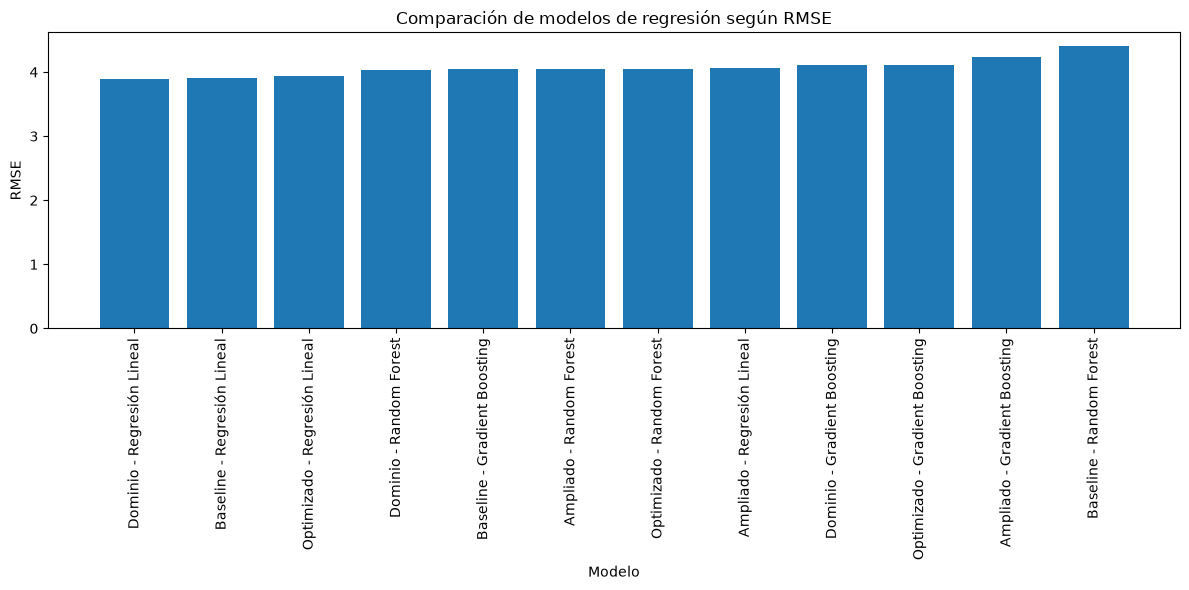

In [50]:
resultados_ordenados = resultados_completos.sort_values("RMSE_Test")

plt.figure(figsize=(12,6))

plt.bar(
    resultados_ordenados["Dataset"] + " - " + resultados_ordenados["Modelo"],
    resultados_ordenados["RMSE_Test"]
)

plt.title("Comparación de modelos de regresión según RMSE")
plt.xlabel("Modelo")
plt.ylabel("RMSE")

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    ruta_figures / "comparacion_rmse_regresion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

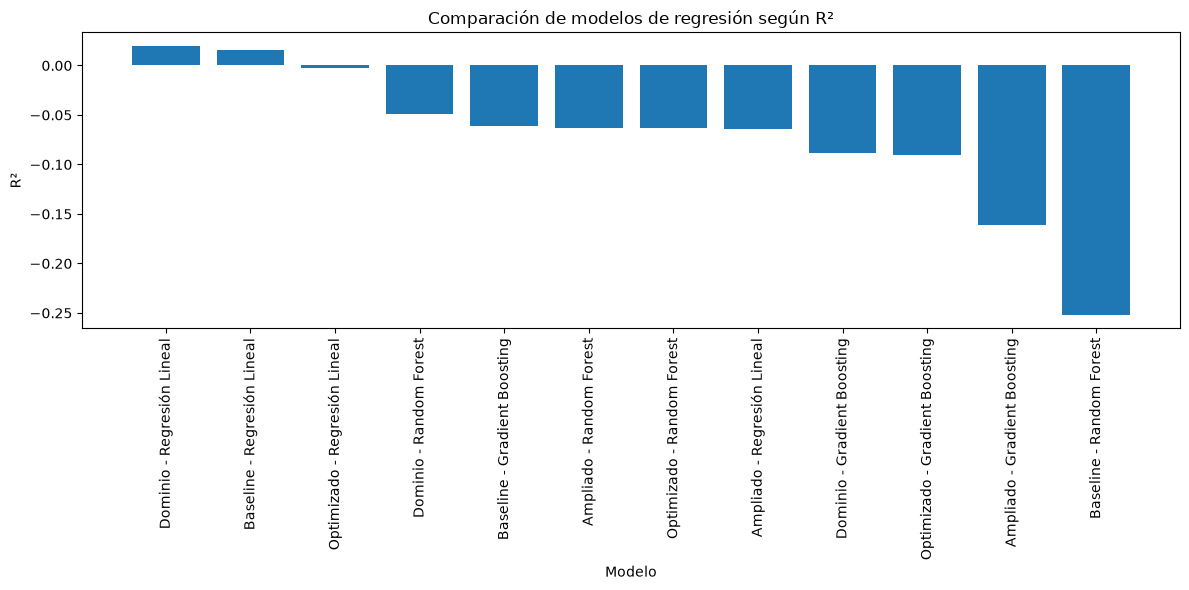

In [51]:
resultados_ordenados = resultados_completos.sort_values("R2_Test", ascending=False)

plt.figure(figsize=(12,6))

plt.bar(
    resultados_ordenados["Dataset"] + " - " + resultados_ordenados["Modelo"],
    resultados_ordenados["R2_Test"]
)

plt.title("Comparación de modelos de regresión según R²")
plt.xlabel("Modelo")
plt.ylabel("R²")

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    ruta_figures / "comparacion_r2_regresion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

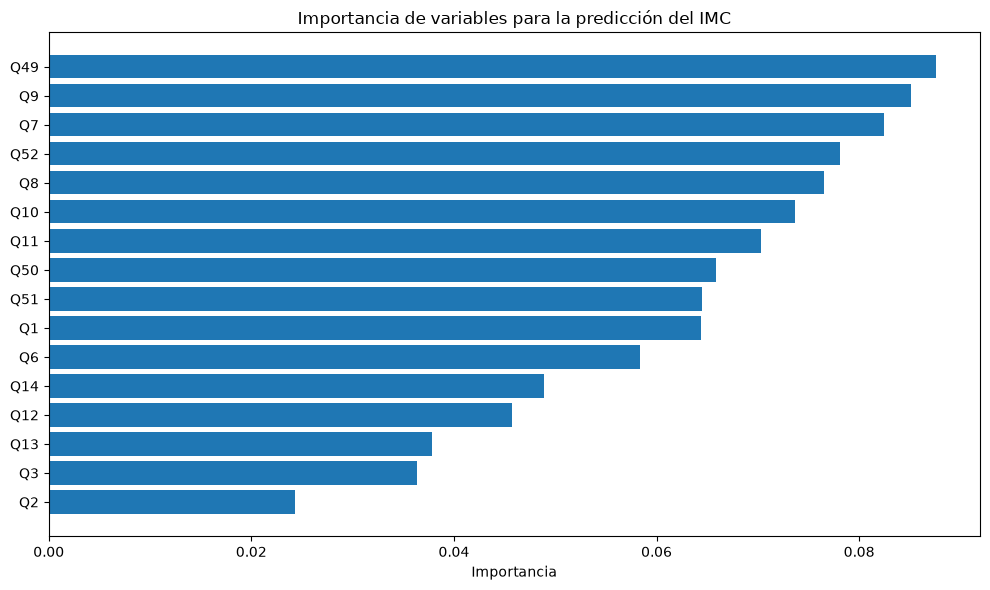

In [52]:
plt.figure(figsize=(10,6))

plt.barh(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.title("Importancia de variables para la predicción del IMC")
plt.xlabel("Importancia")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    ruta_figures / "importancia_variables_regresion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Selección del Modelo Final

Se evaluaron tres estrategias de selección de variables:

- Modelo Baseline.
- Modelo dirigido por el conocimiento del dominio.
- Modelo ampliado.
- Modelo optimizado mediante selección automática.

Cada estrategia fue evaluada utilizando tres algoritmos de regresión:

- Regresión Lineal.
- Random Forest Regressor.
- Gradient Boosting Regressor.

El criterio de selección fue minimizar el RMSE y maximizar el coeficiente de determinación R².

Los resultados obtenidos muestran que el modelo de Regresión Lineal utilizando el conjunto de variables dirigido por el conocimiento del dominio presentó el mejor desempeño, alcanzando:

- RMSE = 3.893
- MAE = 2.985
- R² = 0.0199

Por esta razón dicho modelo fue seleccionado como el modelo final para la estimación del Índice de Masa Corporal.